# Project Overview: Customer Churn Prediction (ANN)

In this notebook, we build an end-to-end **customer churn prediction** workflow using the *Churn Modelling* dataset. We start by loading and inspecting the data, checking its structure and basic distributions (such as how many customers exited).

Next, we perform **data preprocessing**: removing non-informative identifier columns, converting categorical variables (Geography and Gender) into numeric form using one-hot encoding, and splitting the dataset into **training** and **testing** sets. Since neural networks are sensitive to feature scales, we standardize the input features using a **StandardScaler**.

Finally, we create and train an **Artificial Neural Network (ANN)** with Keras/TensorFlow, monitor training/validation performance across epochs, and evaluate the model on the test set using **accuracy** (current test accuracy: `acc = 0.8608`).

In [61]:
import pandas as pd
import numpy as np

In [62]:
df = pd.read_csv(r"C:\Users\rauna\codes\datasets\Churn_Modelling.csv")

In [63]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [67]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [68]:
df.drop(columns=["RowNumber","Surname","CustomerId"], inplace=True)

In [69]:
df = pd.get_dummies(df,columns=["Geography", "Gender"], drop_first=True, dtype=int)

In [70]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  int64  
 10  Geography_Spain    10000 non-null  int64  
 11  Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [72]:
x = df.drop(columns=["Exited"])
y = df["Exited"]

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=42)

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [75]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [90]:
model = Sequential()

In [91]:
model.add(Dense(11,activation="relu" ,input_dim = 11))
model.add(Dense(11, activation="relu"))
model.add(Dense(1,activation="sigmoid"))

c:\Users\rauna\anaconda3\envs\anime_venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])

In [112]:
history = model.fit(x_train_scaled,y_train, epochs=50, validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8665 - loss: 0.3204 - val_accuracy: 0.8520 - val_loss: 0.3503
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8680 - loss: 0.3197 - val_accuracy: 0.8520 - val_loss: 0.3505
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8683 - loss: 0.3195 - val_accuracy: 0.8547 - val_loss: 0.3536
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8668 - loss: 0.3198 - val_accuracy: 0.8573 - val_loss: 0.3517
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8667 - loss: 0.3197 - val_accuracy: 0.8553 - val_loss: 0.3536
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8682 - loss: 0.3191 - val_accuracy: 0.8553 - val_loss: 0.3504
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8673 - loss: 0.3192 - val_accuracy: 0.8547 - val_loss: 0.3529
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8672 - loss: 0.3193 - val_accuracy: 0.

In [113]:
model.layers[1].get_weights()

[array([[-0.89330745, -0.47010177,  0.54369533,  0.6947104 , -0.47697595,
          0.32389155, -0.70659655, -0.23251528, -0.7148263 , -0.3803651 ,
          0.21477947],
        [ 0.67422235,  0.20508358,  0.9283924 ,  0.33374217,  0.33393875,
         -0.18626523, -0.16665262, -0.3115355 ,  0.13007309,  0.780763  ,
          0.31108162],
        [ 0.21843164, -0.18334296,  0.40957752,  0.6291454 , -1.4163334 ,
         -0.62192225,  0.34947667, -0.14352952, -0.43392205,  0.38612914,
          0.20293042],
        [ 0.32604575, -0.2639661 ,  0.32182473,  0.13755701,  0.49315366,
          0.21861334,  0.05487277, -1.5404094 ,  0.54525864, -0.46875608,
         -0.39783376],
        [ 0.42100522,  0.14733686, -0.08652355,  0.33774605, -0.5105268 ,
         -0.29651463,  0.43295184,  0.34713888, -0.4032235 , -0.0843336 ,
         -0.17562246],
        [ 0.18020752,  0.25323173, -0.09332818,  0.4494488 ,  0.02038116,
          0.5970631 ,  0.24820884,  0.33532038, -0.39479882, -0.5474799

In [114]:
y_log = model.predict(x_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step


In [115]:
y_pred = np.where(y_log>0.5,1,0)

In [116]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test,y_pred)

In [117]:
acc

0.8608

In [118]:
import matplotlib.pyplot as plt
history.history

{'accuracy': [0.8665000200271606,
  0.8679999709129333,
  0.8683333396911621,
  0.8668333292007446,
  0.8666666746139526,
  0.8681666851043701,
  0.8673333525657654,
  0.8671666383743286,
  0.8683333396911621,
  0.8668333292007446,
  0.8690000176429749,
  0.8681666851043701,
  0.8681666851043701,
  0.8679999709129333,
  0.8683333396911621,
  0.8668333292007446,
  0.8656666874885559,
  0.8665000200271606,
  0.8666666746139526,
  0.8671666383743286,
  0.8678333163261414,
  0.8661666512489319,
  0.8679999709129333,
  0.8661666512489319,
  0.8686666488647461,
  0.8679999709129333,
  0.8679999709129333,
  0.8688333630561829,
  0.8675000071525574,
  0.8684999942779541,
  0.8688333630561829,
  0.8675000071525574,
  0.8683333396911621,
  0.8681666851043701,
  0.8676666617393494,
  0.8676666617393494,
  0.8675000071525574,
  0.8686666488647461,
  0.8673333525657654,
  0.8693333268165588,
  0.8676666617393494,
  0.8698333501815796,
  0.8706666827201843,
  0.8678333163261414,
  0.8676666617393494

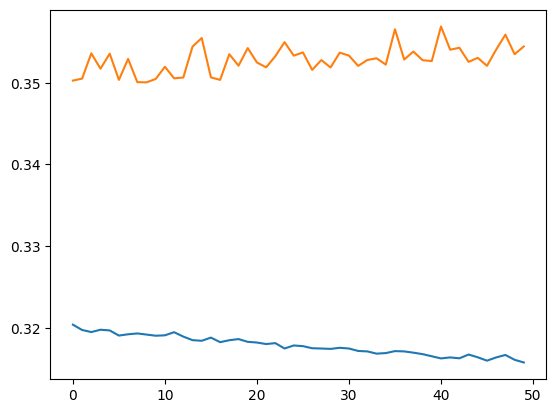

In [119]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

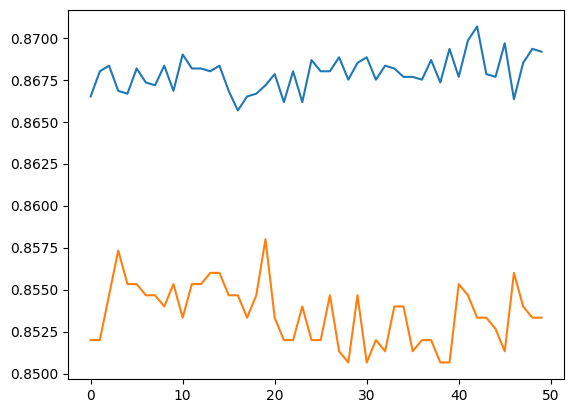

In [120]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])